In [1]:
import os
import os.path as osp
import warnings
from copy import deepcopy
from PIL import Image
import numpy as np
import torch
import cv2

import mmcv
from mmengine import ConfigDict
from mmengine.config import Config, DictAction
from mmengine.runner import Runner
from mmcv.transforms import Compose

from mmdet.engine.hooks.utils import trigger_visualization_hook
from mmdet.evaluation import DumpDetResults
from mmdet.registry import RUNNERS
from mmdet.utils import setup_cache_size_limit_of_dynamo, get_test_pipeline_cfg
from mmdet.apis import inference_detector

import repvit

In [2]:
# Choose to use a config and initialize the detector
config = "configs/faster_rcnn/faster-rcnn_r50_fpn_1x_coco_ben.py"
# Setup a checkpoint file to load
checkpoint = (
    "work_dirs/faster-rcnn_r50_fpn_1x_coco_ben/epoch_12.pth"
)
setup_cache_size_limit_of_dynamo()
cfg = Config.fromfile(config)
cfg.work_dir = osp.join('./work_dirs',
                                osp.splitext(osp.basename(config))[0])
cfg.load_from = checkpoint
# cfg = trigger_visualization_hook(cfg)

In [3]:
runner = Runner.from_cfg(cfg)

05/12 02:25:40 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.10.17 | packaged by conda-forge | (main, Apr 10 2025, 22:19:12) [GCC 13.3.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 15038010
    GPU 0: NVIDIA L4
    CUDA_HOME: /usr/local/cuda-12.6
    NVCC: Cuda compilation tools, release 12.6, V12.6.85
    GCC: gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 1.13.0+cu117
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201402
  - Intel(R) Math Kernel Library Version 2020.0.0 Product Build 20191122 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.6.0 (Git Hash 52b5f107dd9cf10910aaa19cb47f3abf9b349815)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA Runtime 11.7
  - NVCC architecture flags: -gencode;arch=compute_

In [4]:
def inference_detector(model, img_path):
    # Read the image
    img = mmcv.imread(img_path, channel_order='rgb')
    if img is None:
        print(f"Failed to read image: {img_path}")
        return None, None
        
    # Get original image shape for visualization later
    ori_img = img.copy()
    
    # Create a proper data_sample instead of None
    from mmdet.structures import DetDataSample
    data_sample = DetDataSample()
    data_sample.set_metainfo({
        'img_shape': img.shape[:2],  # (H, W)
        'scale_factor': (1.0, 1.0),  # No scaling
        'ori_shape': img.shape[:2],  # Original shape
    })
    
    # Convert to the format MMDetection expects
    data = dict(
        inputs=torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).float().contiguous(),
        data_samples=[data_sample]  # Note: this needs to be a list
    )
    
    # Perform inference
    with torch.no_grad():
        results = model.test_step(data)
        return results[0]

In [20]:
img_path = "data/coco/val2017/datasetfootage_mp4-1_jpg.rf.d2d1f2841af63a0bdbbd58e8da0e8b2a.jpg"
vis = runner.build_visualizer()
image = Image.open(img_path)
vis.set_image(np.array(image))

In [21]:
result = inference_detector(runner.model, img_path)

In [22]:
result.pred_instances.bboxes[:10]

tensor([[270.4022, 815.3364, 271.2347, 816.8424],
        [264.1196, 817.7216, 273.6335, 818.0582],
        [593.5098, 238.0833, 604.0228, 239.3274],
        [110.0003, 755.6121, 110.2989, 756.0018],
        [429.0247,   8.3020, 429.4344,  13.6218],
        [395.8954,  68.9862, 396.4822,  77.4372],
        [554.4798, 141.2159, 555.2379, 146.7262],
        [278.9374, 796.4059, 280.0527, 810.4973],
        [490.8623,  59.9273, 491.4332,  66.0956],
        [257.6374, 448.0107, 319.1644, 448.3354]], device='cuda:0')

In [25]:
vis.draw_bboxes(result.pred_instances.bboxes[:20])

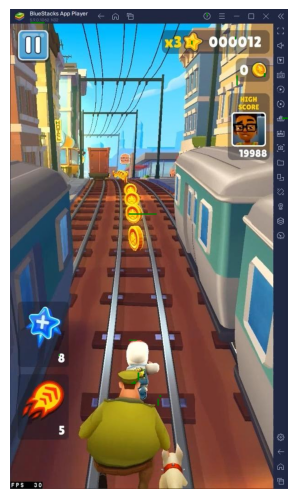

In [26]:
vis.show()